In [1]:
import pandas as pd
import numpy as np

In [4]:
df_clean = pd.read_csv("../data/processed/HHS_Clean_Dataset.csv")
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean = df_clean.sort_values("Date")
df_clean = df_clean.set_index("Date")

In [5]:
feature_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children discharged from HHS Care",
    "Month",
    "Day",
    "Year",
    "Quarter",
    "Day_of_Week",
    "Is_Weekend",
    "HHS_Lag_1",
    "HHS_Lag_7",
    "HHS_Lag_14",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_STD_7",
    "Net_Pressure"
]

X = df_clean[feature_cols]
y = df_clean["Children in HHS Care"]

In [6]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [7]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

mae = mean_absolute_error(y_test, gb_pred)
rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
mape = mean_absolute_percentage_error(y_test, gb_pred)

print(f"Gradient Boosting MAE  : {mae:.2f}")
print(f"Gradient Boosting RMSE : {rmse:.2f}")
print(f"Gradient Boosting MAPE : {mape*100:.2f}%")

Gradient Boosting MAE  : 58.79
Gradient Boosting RMSE : 79.32
Gradient Boosting MAPE : 2.70%


                                            Feature  Importance
10                                        HHS_Lag_1    0.747015
13                                   Rolling_Mean_7    0.170773
11                                        HHS_Lag_7    0.043503
14                                  Rolling_Mean_14    0.021059
12                                       HHS_Lag_14    0.009064
4                                             Month    0.004094
1                           Children in CBP custody    0.000972
15                                    Rolling_STD_7    0.000655
0   Children apprehended and placed in CBP custody*    0.000546
8                                       Day_of_Week    0.000493
6                                              Year    0.000457
16                                     Net_Pressure    0.000448
2           Children transferred out of CBP custody    0.000344
9                                        Is_Weekend    0.000327
7                                       

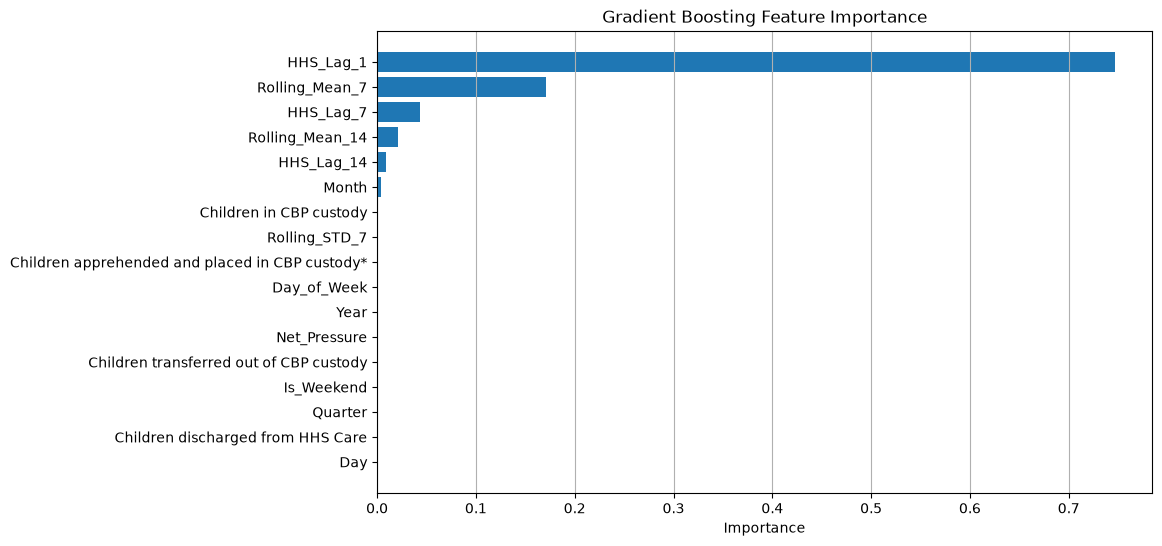

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [8]:
import joblib

joblib.dump(gb_model, "../models/gradient_boosting_model.pkl")

['../models/gradient_boosting_model.pkl']